parallel workflow
structured output
reducer function-- add

In [46]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
import os

In [47]:
load_dotenv ()
model = ChatGroq(
    groq_api_key=os.getenv("GROQ_API_KEY") ,
    model="llama-3.3-70b-versatile"
)

In [48]:
class EvalSchema(BaseModel):

    feedback: str=Field(description='detailed feedback for the essay')
    score : int =Field(description='score out of 10',ge=0,le=10)

In [49]:
structured_model=model.with_structured_output(EvalSchema)

In [50]:
essay="""Artificial Intelligence (AI) is one of the most transformative technologies of the 21st century. It refers to the simulation of human intelligence by machines, particularly computer systems, to perform tasks that typically require human cognition — such as learning, reasoning, problem-solving, and decision-making. From self-driving cars to personalized recommendations on Netflix, AI has rapidly become an integral part of modern life.
The concept of AI dates back to the mid-20th century. In 1956, the term “Artificial Intelligence” was coined at the Dartmouth Conference, marking the birth of the field. Early AI systems focused on symbolic reasoning and logic, but they were limited by computational power and data availability.
With the advent of machine learning and deep learning in the 21st century, AI witnessed a revolution. Algorithms began learning patterns from massive datasets, allowing systems to improve automatically without explicit programming. Today, AI research extends into advanced areas such as neural networks, natural language processing, and generative AI.
"""

In [51]:
essay2="""Artificial Intelligence (AI) stands at the confluence of human ingenuity and technological evolution — a phenomenon reshaping how the world perceives intelligence itself. Defined as the capability of machines to emulate cognitive functions such as learning, reasoning, and decision-making, AI transcends mere automation; it represents the pursuit of synthetic cognition. In an era driven by data, connectivity, and computation, AI has emerged not only as a tool of efficiency but as a catalyst of transformation across industries, economies, and societies.
The Evolution of Artificial Intelligence

The intellectual foundations of AI trace back to the mid-20th century when pioneers like Alan Turing and John McCarthy questioned whether machines could think. The decades that followed saw cycles of optimism and stagnation — the so-called AI winters — marked by technological limitations and inflated expectations. However, the proliferation of big data, exponential increases in processing power, and the rise of neural networks revitalized the field.
Contemporary AI is no longer confined to symbolic reasoning; it now thrives through machine learning, deep learning, and generative models, enabling systems to identify patterns, infer meaning, and even create original content. The transition from rule-based intelligence to adaptive learning marks the true revolution of modern AI."""

In [52]:
prompt=f"evaluate the language quality of the following essay and provide a feedback and assign a score  out of 10\n {essay}"

structured_model.invoke(prompt)

EvalSchema(feedback='The essay provides a clear and concise introduction to the concept of Artificial Intelligence, its history, and its evolution. The language quality is good, with proper use of technical terms and concepts. The essay is well-structured and easy to follow. However, it could benefit from more specific examples and a deeper analysis of the impact of AI on modern life. Additionally, some sentences are a bit simplistic and lack variety in terms of sentence structure and vocabulary.', score=8)

In [53]:
class UPSCstate(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_of_thought_feedback: str
    overall_feedback: str
    individual_score: Annotated[list[int],operator.add] #reducer function - add
    avg_score: float

In [54]:
def evaluate_language(state: UPSCstate):

    prompt=f"evaluate the language quality of the following essay and provide a feedback and assign a score  out of 10\n {state['essay']}"
    output=structured_model.invoke(prompt)

    return {'language_feedback':output.feedback,'individual_score':[output.score]}

In [55]:
def evaluate_analysis(state: UPSCstate):

    prompt=f"evaluate the deph of analysis of the following essay and provide a feedback and assign a score  out of 10\n {state['essay']}"
    output=structured_model.invoke(prompt)

    return {'analysis_feedback':output.feedback,'individual_score':[output.score]}

In [56]:
def evaluate_cot(state: UPSCstate):

    prompt=f"evaluate the clarity of thought of the following essay and provide a feedback and assign a score  out of 10\n {state['essay']}"
    output=structured_model.invoke(prompt)

    return {'clarity_of_thought_feedback':output.feedback,'individual_score':[output.score]}

In [57]:
def final_evaluation(state: UPSCstate):

    #summary feedback
    prompt=f'based on the following ceate a summarized feedback \n language feedback- {state["language_feedback"]} \n depth of analysis of feedback- {state["analysis_feedback"]} \n clarity of thought feddback- {state["clarity_of_thought_feedback"]}'
    overall_feedback=model.invoke(prompt).content

    #avg score
    avg_score=sum(state['individual_score'])/len(state['individual_score'])

    return {'overall_feedback':overall_feedback,'avg_score': avg_score}

In [58]:
graph=StateGraph(UPSCstate)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_cot',evaluate_cot)
graph.add_node('final_evaluation',final_evaluation)

graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_cot')

graph.add_edge('evaluate_language','final_evaluation')
graph.add_edge('evaluate_analysis','final_evaluation')
graph.add_edge('evaluate_cot','final_evaluation')

graph.add_edge('final_evaluation',END)

workflow=graph.compile()

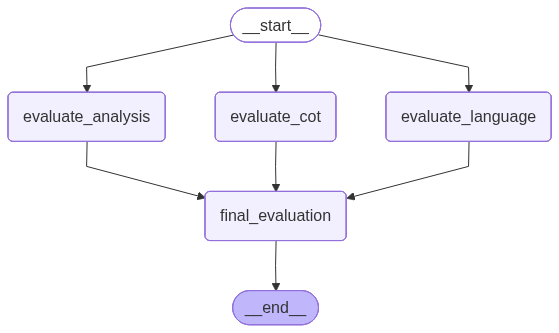

In [59]:
workflow

In [60]:
initial_state={
    'essay':essay
}

workflow.invoke(initial_state)

{'essay': 'Artificial Intelligence (AI) is one of the most transformative technologies of the 21st century. It refers to the simulation of human intelligence by machines, particularly computer systems, to perform tasks that typically require human cognition — such as learning, reasoning, problem-solving, and decision-making. From self-driving cars to personalized recommendations on Netflix, AI has rapidly become an integral part of modern life.\nThe concept of AI dates back to the mid-20th century. In 1956, the term “Artificial Intelligence” was coined at the Dartmouth Conference, marking the birth of the field. Early AI systems focused on symbolic reasoning and logic, but they were limited by computational power and data availability.\nWith the advent of machine learning and deep learning in the 21st century, AI witnessed a revolution. Algorithms began learning patterns from massive datasets, allowing systems to improve automatically without explicit programming. Today, AI research ex

In [61]:
initial_state={
    'essay':essay2
}

workflow.invoke(initial_state)

{'essay': 'Artificial Intelligence (AI) stands at the confluence of human ingenuity and technological evolution — a phenomenon reshaping how the world perceives intelligence itself. Defined as the capability of machines to emulate cognitive functions such as learning, reasoning, and decision-making, AI transcends mere automation; it represents the pursuit of synthetic cognition. In an era driven by data, connectivity, and computation, AI has emerged not only as a tool of efficiency but as a catalyst of transformation across industries, economies, and societies.\nThe Evolution of Artificial Intelligence\n\nThe intellectual foundations of AI trace back to the mid-20th century when pioneers like Alan Turing and John McCarthy questioned whether machines could think. The decades that followed saw cycles of optimism and stagnation — the so-called AI winters — marked by technological limitations and inflated expectations. However, the proliferation of big data, exponential increases in proces